<a href="https://colab.research.google.com/github/NehaKhann/ai-engineering-journey/blob/main/weeks/week-03-efficient-fine-tuning/bonus-lora-large-dataset/lora_large_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bonus — LoRA Training on a Real, Larger Dataset

**Week 3 Enhancement (builds on Day 2)**

## The problem this fixes

In Day 2's demo, LoRA was trained on just **4 hardcoded toy examples** for 20 repeated steps. Afterward, asking the model a brand-new trivia question — *"What is the capital of Japan?"* — sometimes returned a corrupted answer like **"Beijing"** instead of "Tokyo."

This is called **catastrophic forgetting**. It happens because:
- The training set is tiny (4 examples) and highly repetitive (looped 5x over 20 steps)
- With so little diversity, the optimizer doesn't learn a general pattern — it memorizes those 4 exact input/output pairs, and in doing so, overwrites unrelated knowledge the base model already had

**The fix isn't a different LoRA setting — it's training data.** This notebook trains the *exact same* LoRA configuration from Day 2, but on thousands of diverse, real instruction-following examples pulled live from the Hugging Face `datasets` library — no hardcoded JSON anywhere in this notebook.

## How we prove the fix worked

1. **Regression check** — ask the same trivia questions from Day 2, before and after training. If forgetting is fixed, these should stay correct.
2. **Held-out perplexity** — a quantitative score of how well the model predicts text it never saw during training. This should *improve* (get lower) after training on real data — the opposite of what happens when a model overfits to a handful of examples.

In [1]:
!pip install -q -U torchao
!pip install -q -U transformers peft accelerate datasets matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth 2025.11.1 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.0,<=4.57.2,>=4.51.3, but you have transformers 5.14.1 which is incompatible.
unsloth-zoo 2025.11.2 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,<=4.57.2,>=4.51.3, but you have transformers 5.14.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import time
from dataclasses import dataclass, asdict

import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

# Alpaca: ~52,000 diverse instruction/response pairs, publicly available,
# no login required. Swap for "databricks/databricks-dolly-15k" if you
# want an alternative (field names differ slightly — see the README).
DATASET_NAME = "tatsu-lab/alpaca"

NUM_TRAIN_EXAMPLES = 2000   # real training data, vs Day 2's 4 examples
NUM_VAL_EXAMPLES = 200      # held out, never trained on — used for perplexity
MAX_SEQ_LENGTH = 256
LORA_RANK = 8               # same as Day 2, so this is an apples-to-apples fix
LORA_ALPHA = 16
LEARNING_RATE = 2e-4

# The exact kind of question that broke in Day 2's demo — used here as a
# regression check, not as training data.
REGRESSION_PROMPTS = [
    "What is the capital of Japan?",
    "What is the capital of France?",
    "What is 12 multiplied by 8?",
    "Name the largest planet in our solar system.",
]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0727 21:16:31.739000 26856 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Step 1 — Load a REAL dataset from the Hugging Face Hub

No hardcoded JSON here — `load_dataset()` downloads real, diverse instruction data. We filter to single-turn examples (no extra `input` context) so every example has the same simple shape, then split into a training set and a **held-out validation set** the model never trains on.

In [3]:
print(f"Downloading '{DATASET_NAME}' from the Hugging Face Hub...")
raw = load_dataset(DATASET_NAME, split="train")

raw = raw.filter(lambda x: x["input"].strip() == "")
raw = raw.shuffle(seed=42)

total_needed = NUM_TRAIN_EXAMPLES + NUM_VAL_EXAMPLES
train_data = raw.select(range(NUM_TRAIN_EXAMPLES))
val_data = raw.select(range(NUM_TRAIN_EXAMPLES, total_needed))

print(f"Loaded {len(train_data)} training examples, {len(val_data)} held-out validation examples.")
print("\nExample training row:")
print(train_data[0])

Loaded 2000 training examples, 200 held-out validation examples.

Example training row:
{'instruction': 'Name two green vegetables.', 'input': '', 'output': 'Spinach and broccoli.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nName two green vegetables.\n\n### Response:\nSpinach and broccoli.'}


## Helper functions

In [4]:
def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters())


def count_trainable_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_training_batch(tokenizer, instruction: str, response: str, device):
    messages = [
        {"role": "user", "content": instruction},
        {"role": "assistant", "content": response},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH)
    encoded["labels"] = encoded["input_ids"].clone()
    return {k: v.to(device) for k, v in encoded.items()}


def generate_response(model, tokenizer, prompt: str, max_new_tokens: int = 40) -> str:
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    input_len = inputs["input_ids"].shape[-1]
    return tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True).strip()


def compute_perplexity(model, tokenizer, val_data, device, sample_size: int = 50) -> float:
    """Lower perplexity = the model is less 'surprised' by held-out text = better general understanding."""
    model.eval()
    losses = []
    for item in val_data.select(range(min(sample_size, len(val_data)))):
        batch = build_training_batch(tokenizer, item["instruction"], item["output"], device)
        with torch.no_grad():
            outputs = model(**batch)
        losses.append(outputs.loss.item())
    avg_loss = sum(losses) / len(losses)
    return torch.exp(torch.tensor(avg_loss)).item()

## Step 2 — Load the base model and check it BEFORE training

This is the regression check baseline, plus a held-out perplexity score — both measured before any training happens.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device)
total_params = count_params(base_model)

print("--- BEFORE training ---")
regression_before = {}
for prompt in REGRESSION_PROMPTS:
    response = generate_response(base_model, tokenizer, prompt)
    print(f"Q: {prompt}\nA: {response}\n")
    regression_before[prompt] = response

perplexity_before = compute_perplexity(base_model, tokenizer, val_data, device)
print(f"Held-out perplexity BEFORE training: {perplexity_before:.2f}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 305.35it/s]


--- BEFORE training ---
Q: What is the capital of Japan?
A: The capital of Japan is Tokyo.

Q: What is the capital of France?
A: The capital of France is Paris.

Q: What is 12 multiplied by 8?
A: To solve the problem of multiplying 12 by 8, you simply add 12 to itself eight times:

\[ 12 \times 8 = (10 + 2)

Q: Name the largest planet in our solar system.
A: The largest planet in our solar system is Jupiter.

Jupiter is the fifth planet from the Sun and the largest planet in the Solar System. It has a diameter of approximately 142,9

Held-out perplexity BEFORE training: 18.76


## Step 3 — Attach LoRA (identical config to Day 2)

Same rank, same alpha, same target modules as Day 2 — the only thing changing in this notebook is the training data, so any improvement we see is attributable to that, not a different adapter setup.

In [6]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)
model = get_peft_model(base_model, lora_config)
trainable = count_trainable_params(model)
pct = 100 * trainable / total_params
print(f"Trainable parameters: {trainable:,} ({pct:.3f}% of full model)")

Trainable parameters: 540,672 (0.109% of full model)


## Step 4 — Train on 2,000 real examples (one full epoch)

This is the actual fix: instead of looping 4 examples 20 times, we do a single pass over 2,000 diverse, real examples. Watch the loss print periodically — a real dataset produces a noisy but generally downward trend, not the abrupt collapse you'd get from memorizing 4 repeated strings.

In [7]:
model.train()
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)

loss_history = []
final_loss = 0.0

print(f"Training on {len(train_data)} real examples (1 epoch)...")
t0 = time.time()
for step, item in enumerate(train_data):
    batch = build_training_batch(tokenizer, item["instruction"], item["output"], device)

    outputs = model(**batch)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    final_loss = loss.item()
    loss_history.append(final_loss)

    if step % 200 == 0:
        print(f"  step {step:>5}/{len(train_data)}  loss={final_loss:.4f}")

train_time = time.time() - t0
print(f"\nTraining done in {train_time:.1f}s, final loss={final_loss:.4f}")

Training on 2000 real examples (1 epoch)...
  step     0/2000  loss=4.5698
  step   200/2000  loss=1.4177
  step   400/2000  loss=1.3925
  step   600/2000  loss=0.9360
  step   800/2000  loss=0.9370
  step  1000/2000  loss=1.0127
  step  1200/2000  loss=1.6157
  step  1400/2000  loss=0.4487
  step  1600/2000  loss=0.7097
  step  1800/2000  loss=2.0264

Training done in 698.6s, final loss=1.3322


## Step 5 — Check the model AFTER training

Same regression questions, same held-out perplexity measurement — now on the trained model.

In [8]:
model.eval()
print("--- AFTER training ---")
regression_after = {}
for prompt in REGRESSION_PROMPTS:
    response = generate_response(model, tokenizer, prompt)
    print(f"Q: {prompt}\nA: {response}\n")
    regression_after[prompt] = response

perplexity_after = compute_perplexity(model, tokenizer, val_data, device)
print(f"Held-out perplexity AFTER training: {perplexity_after:.2f}")

--- AFTER training ---
Q: What is the capital of Japan?
A: The capital of Japan is Tokyo.

Q: What is the capital of France?
A: The capital of France is Paris.

Q: What is 12 multiplied by 8?
A: The answer to 12 multiplied by 8 is 96.

Q: Name the largest planet in our solar system.
A: The largest planet in our solar system is Jupiter.

Held-out perplexity AFTER training: 3.33


## Step 6 — Compare before vs. after directly

In [9]:
print(f"{'=' * 60}\nREGRESSION CHECK — did basic knowledge survive training?\n{'=' * 60}")
for prompt in REGRESSION_PROMPTS:
    before = regression_before[prompt]
    after = regression_after[prompt]
    changed = "CHANGED" if before != after else "same"
    print(f"[{changed}] {prompt}")
    print(f"   before: {before}")
    print(f"   after:  {after}")

print(f"\nPerplexity before: {perplexity_before:.2f}  |  after: {perplexity_after:.2f}")
print("(Lower is better. A drop here means the model generalized; a corrupted")
print(" regression answer alongside a WORSE perplexity would indicate forgetting.)")

REGRESSION CHECK — did basic knowledge survive training?
[same] What is the capital of Japan?
   before: The capital of Japan is Tokyo.
   after:  The capital of Japan is Tokyo.
[same] What is the capital of France?
   before: The capital of France is Paris.
   after:  The capital of France is Paris.
[CHANGED] What is 12 multiplied by 8?
   before: To solve the problem of multiplying 12 by 8, you simply add 12 to itself eight times:

\[ 12 \times 8 = (10 + 2)
   after:  The answer to 12 multiplied by 8 is 96.
[CHANGED] Name the largest planet in our solar system.
   before: The largest planet in our solar system is Jupiter.

Jupiter is the fifth planet from the Sun and the largest planet in the Solar System. It has a diameter of approximately 142,9
   after:  The largest planet in our solar system is Jupiter.

Perplexity before: 18.76  |  after: 3.33
(Lower is better. A drop here means the model generalized; a corrupted
 regression answer alongside a WORSE perplexity would indicate for

## Step 7 — Visualize the training loss curve

A real, diverse dataset produces a noisy-but-decreasing loss curve over many steps — very different from Day 2's 20-step demo, where loss on 4 repeated examples can crash toward zero almost immediately (a visual sign of memorization, not learning).

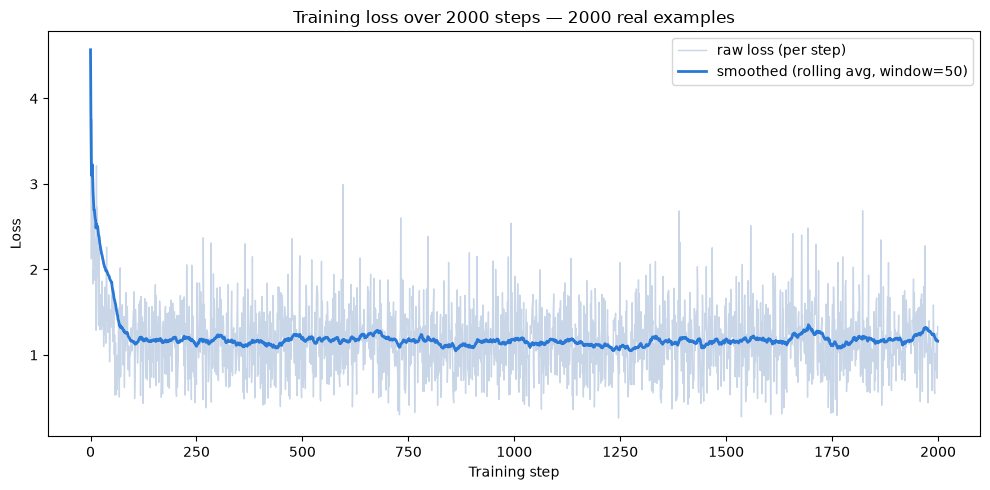

Saved to training_loss_curve.png


In [10]:
import matplotlib.pyplot as plt

window = 50
smoothed = [
    sum(loss_history[max(0, i - window):i + 1]) / len(loss_history[max(0, i - window):i + 1])
    for i in range(len(loss_history))
]

plt.figure(figsize=(10, 5))
plt.plot(loss_history, color="#c9d6e8", linewidth=1, label="raw loss (per step)")
plt.plot(smoothed, color="#2a78d6", linewidth=2, label=f"smoothed (rolling avg, window={window})")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title(f"Training loss over {len(loss_history)} steps — {NUM_TRAIN_EXAMPLES} real examples")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to training_loss_curve.png")

In [11]:
result = {
    "dataset": DATASET_NAME,
    "num_train_examples": NUM_TRAIN_EXAMPLES,
    "num_val_examples": NUM_VAL_EXAMPLES,
    "trainable_params": trainable,
    "total_params": total_params,
    "trainable_pct": round(pct, 4),
    "train_time_sec": round(train_time, 1),
    "final_train_loss": round(final_loss, 4),
    "perplexity_before": round(perplexity_before, 2),
    "perplexity_after": round(perplexity_after, 2),
    "regression_checks": [
        {"prompt": p, "before": regression_before[p], "after": regression_after[p]}
        for p in REGRESSION_PROMPTS
    ],
}

with open("experiment_log.json", "w") as f:
    json.dump(result, f, indent=2)
print("Saved full results to experiment_log.json")

Saved full results to experiment_log.json


## What to look for

1. **Regression prompts unchanged or still correct** — the clearest sign the "Beijing" bug is fixed. A little wording variation is fine; a wrong *fact* is not.
2. **Perplexity after < perplexity before** — quantitative proof the model generalized to text it never saw, rather than just memorizing training examples.
3. **Loss curve** — noisy but trending downward over 2,000 steps, not an instant collapse to near-zero (which would be a red flag for memorization on too little data).

## Key takeaway

The LoRA configuration itself (`r=8`, `alpha=16`, same target modules) was never the problem in Day 2 — the training data was. Swapping 4 hardcoded examples for 2,000 real ones, with zero other changes, is what fixes catastrophic forgetting here.